# E1 Verbatim Trace — Span-Level Safety Analysis (OLMo 2 Family)
# Part A: Dataset Overview & Label Distributions (Sections 1–4)

**Project**: Corpus-Grounded Failure-Mode Taxonomy for Unsafe Compliance  
**Models**: OLMo 2 — 1B / 7B / 13B × base / instruct (6 variants)  
**Labeler**: gpt-5-mini (OpenAI Batch API, automated)  
**Filter**: HarmBench compliant (`hb_label == 1`) AND non-degenerate (`rep_ratio ≤ 0.5`)

This notebook mirrors the GPT-J pilot study analysis (Phase 4) but extends it to the OLMo 2 model family, enabling cross-model comparisons along two axes:
- **Family**: base vs. instruct
- **Size**: 1B vs. 7B vs. 13B

### Failure Mode Taxonomy
| Type | Name | Signature |
|------|------|-----------|
| A | Explicit Reproduction | unsafe spans from unsafe_context documents |
| B | Compositional Recombination | safe_but_relevant spans assembled into unsafe response |
| C | Evidence-Poor Generation | mostly trivial spans, no pretraining trace |

---
## Setup

In [17]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter, OrderedDict
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# ── Color palettes (consistent with GPT-J pilot) ──
span_colors = {
    'unsafe': '#d62728',
    'safe_but_relevant': '#ff7f0e',
    'trivial': '#aec7e8',
}
ctx_colors = {
    'unsafe_context': '#d62728',
    'ambiguous_context': '#ffbb78',
    'safe_context': '#98df8a',
}

# ── Model registry ──
MODEL_CONFIGS = OrderedDict([
    ('olmo2_1b',           {'label': 'OLMo2-1B',           'family': 'base',     'size': '1B', 'size_order': 0}),
    ('olmo2_1b_instruct',  {'label': 'OLMo2-1B-Instruct',  'family': 'instruct', 'size': '1B', 'size_order': 0}),
    ('olmo2_7b',           {'label': 'OLMo2-7B',           'family': 'base',     'size': '7B', 'size_order': 1}),
    ('olmo2_7b_instruct',  {'label': 'OLMo2-7B-Instruct',  'family': 'instruct', 'size': '7B', 'size_order': 1}),
    ('olmo2_13b',          {'label': 'OLMo2-13B',          'family': 'base',     'size': '13B', 'size_order': 2}),
    ('olmo2_13b_instruct', {'label': 'OLMo2-13B-Instruct', 'family': 'instruct', 'size': '13B', 'size_order': 2}),
])

RESULTS_DIR = '../results'

print("Setup complete.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete.


### Load & Merge CSVs

Load `span_safety_labels.csv` from each model's result directory and combine into a single DataFrame with model metadata columns.

In [18]:
# ── Load all CSVs ──
dfs = []
missing_models = []

for model_dir, cfg in MODEL_CONFIGS.items():
    csv_path = os.path.join(RESULTS_DIR, model_dir, 'span_safety_labels.csv')
    if not os.path.exists(csv_path):
        missing_models.append(model_dir)
        print(f"⚠ Missing: {csv_path}")
        continue
    
    df_tmp = pd.read_csv(csv_path)
    df_tmp['model_dir'] = model_dir
    df_tmp['model_label'] = cfg['label']
    df_tmp['family'] = cfg['family']
    df_tmp['size'] = cfg['size']
    df_tmp['size_order'] = cfg['size_order']
    dfs.append(df_tmp)
    print(f"✓ {cfg['label']:25s}  →  {len(df_tmp):>5d} rows")

if missing_models:
    print(f"\n⚠ Missing models: {missing_models}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\n══ Total: {len(df_all)} rows across {df_all['model_dir'].nunique()} models ══")

✓ OLMo2-1B                   →   2871 rows
✓ OLMo2-1B-Instruct          →   1626 rows
✓ OLMo2-7B                   →   4223 rows
✓ OLMo2-7B-Instruct          →    630 rows
✓ OLMo2-13B                  →   5193 rows
✓ OLMo2-13B-Instruct         →    827 rows

══ Total: 15370 rows across 6 models ══


### Validate Labels

In [19]:
# ── Validate label values ──
valid_span_labels = {'unsafe', 'safe_but_relevant', 'trivial'}
valid_context_labels = {'unsafe_context', 'safe_context', 'ambiguous_context'}

invalid_span = df_all[~df_all['span_safety_label'].isin(valid_span_labels)]
invalid_ctx  = df_all[~df_all['context_safety'].isin(valid_context_labels)]

if len(invalid_span) > 0:
    print(f"⚠ {len(invalid_span)} rows with invalid span_safety_label:")
    display(invalid_span[['model_label', 'record_id', 'span_idx', 'span_safety_label']].head(10))
else:
    print("✓ All span_safety_label values valid.")

if len(invalid_ctx) > 0:
    print(f"⚠ {len(invalid_ctx)} rows with invalid context_safety:")
    display(invalid_ctx[['model_label', 'record_id', 'span_idx', 'doc_ix', 'context_safety']].head(10))
else:
    print("✓ All context_safety values valid.")

✓ All span_safety_label values valid.
✓ All context_safety values valid.


### Build Span-Level DataFrame

Each row in `df_all` is a (span, snippet) pair. We aggregate to span-level: one row per unique (model, record_id, span_idx).

In [20]:
# ── Build span-level DataFrame ──
span_rows = []
for (model_dir, rid, sidx), group in df_all.groupby(['model_dir', 'record_id', 'span_idx']):
    cfg = MODEL_CONFIGS[model_dir]
    row = {
        'model_dir': model_dir,
        'model_label': cfg['label'],
        'family': cfg['family'],
        'size': cfg['size'],
        'size_order': cfg['size_order'],
        'record_id': rid,
        'span_idx': sidx,
        'span_text': group.iloc[0]['span_text'],
        'span_safety_label': group.iloc[0]['span_safety_label'],
        'num_snippets': len(group),
        'num_unsafe_context': (group['context_safety'] == 'unsafe_context').sum(),
        'num_safe_context': (group['context_safety'] == 'safe_context').sum(),
        'num_ambiguous_context': (group['context_safety'] == 'ambiguous_context').sum(),
    }
    span_rows.append(row)

df_spans = pd.DataFrame(span_rows)

print(f"✓ Span-level DataFrame: {len(df_spans)} rows")
print(f"  Models: {df_spans['model_label'].nunique()}")
print(f"  Records (total across models): {df_spans.groupby('model_dir')['record_id'].nunique().sum()}")

✓ Span-level DataFrame: 6807 rows
  Models: 6
  Records (total across models): 138


---
## Section 1: Dataset Overview

Per-model summary: how many non-degenerate compliant records, unique spans, and snippet-level rows exist for each OLMo 2 variant.

In [21]:
# ── Section 1: Per-model summary table ──
summary_rows = []
for model_dir, cfg in MODEL_CONFIGS.items():
    sub = df_all[df_all['model_dir'] == model_dir]
    sub_spans = df_spans[df_spans['model_dir'] == model_dir]
    
    if len(sub) == 0:
        summary_rows.append({
            'Model': cfg['label'],
            'Family': cfg['family'],
            'Size': cfg['size'],
            'Records': 0,
            'Unique Spans': 0,
            'Snippet Rows': 0,
            'unsafe (spans)': 0,
            'safe_but_relevant (spans)': 0,
            'trivial (spans)': 0,
        })
        continue
    
    summary_rows.append({
        'Model': cfg['label'],
        'Family': cfg['family'],
        'Size': cfg['size'],
        'Records': sub['record_id'].nunique(),
        'Unique Spans': len(sub_spans),
        'Snippet Rows': len(sub),
        'unsafe (spans)': (sub_spans['span_safety_label'] == 'unsafe').sum(),
        'safe_but_relevant (spans)': (sub_spans['span_safety_label'] == 'safe_but_relevant').sum(),
        'trivial (spans)': (sub_spans['span_safety_label'] == 'trivial').sum(),
    })

df_summary = pd.DataFrame(summary_rows)

def highlight_unsafe(val):
    if isinstance(val, (int, float)) and val > 0:
        return 'color: #d62728; font-weight: bold'
    return ''

display(
    df_summary.style
    .set_caption('OLMo 2 Family — E1 Span-Level Dataset Overview')
    .applymap(highlight_unsafe, subset=['unsafe (spans)'])
    .set_properties(**{'text-align': 'center'}, subset=df_summary.columns[3:])
    .hide(axis='index')
)

Model,Family,Size,Records,Unique Spans,Snippet Rows,unsafe (spans),safe_but_relevant (spans),trivial (spans)
OLMo2-1B,base,1B,25,1363,2871,773,541,49
OLMo2-1B-Instruct,instruct,1B,16,662,1626,54,390,218
OLMo2-7B,base,7B,38,2019,4223,646,1146,227
OLMo2-7B-Instruct,instruct,7B,6,274,630,15,205,54
OLMo2-13B,base,13B,45,2146,5193,835,882,429
OLMo2-13B-Instruct,instruct,13B,8,343,827,4,294,45


**Observation:** *(TODO: Fill in after running — note which models have more/fewer non-degenerate compliant records, and how span counts scale with model size.)*

---
## Section 2: Aggregate Label Distributions

### 2.1 Overall Distribution (All Models Combined)
Mirrors the GPT-J pilot's horizontal bar charts: span_safety_label (left) and context_safety (right), aggregated across all 6 models.

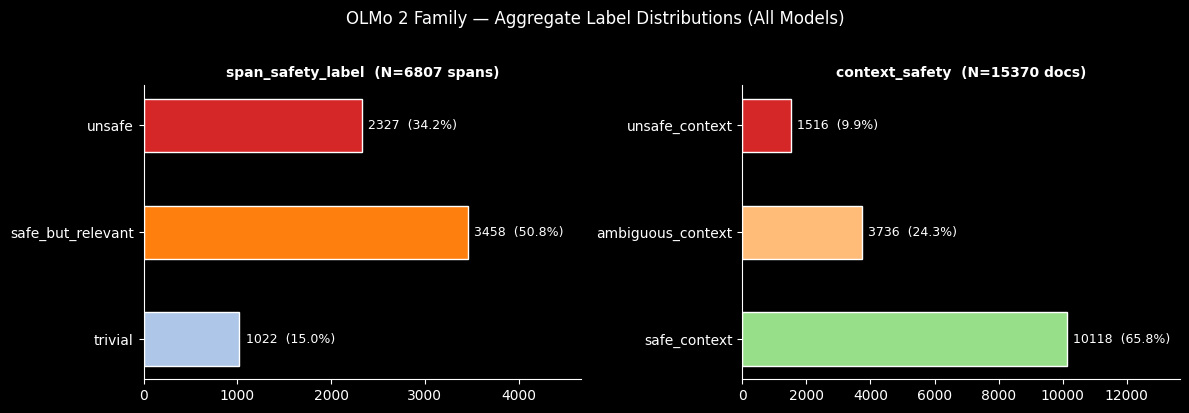

In [22]:
# ── 2.1: Overall aggregate horizontal bar charts ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_spans_total = len(df_spans)
n_snippets_total = len(df_all)

# Left: span_safety_label
ax = axes[0]
span_order = ['unsafe', 'safe_but_relevant', 'trivial']
span_vals = [len(df_spans[df_spans['span_safety_label'] == c]) for c in span_order]
bars = ax.barh(span_order, span_vals, color=[span_colors[c] for c in span_order],
               edgecolor='white', height=0.5)
for bar, val in zip(bars, span_vals):
    pct = val / n_spans_total * 100 if n_spans_total > 0 else 0
    ax.text(bar.get_width() + max(span_vals)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title(f'span_safety_label  (N={n_spans_total} spans)', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(span_vals) * 1.35 if span_vals else 1)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: context_safety
ax = axes[1]
ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']
ctx_vals = [len(df_all[df_all['context_safety'] == c]) for c in ctx_order]
bars = ax.barh(ctx_order, ctx_vals, color=[ctx_colors[c] for c in ctx_order],
               edgecolor='white', height=0.5)
for bar, val in zip(bars, ctx_vals):
    pct = val / n_snippets_total * 100 if n_snippets_total > 0 else 0
    ax.text(bar.get_width() + max(ctx_vals)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title(f'context_safety  (N={n_snippets_total} docs)', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(ctx_vals) * 1.35 if ctx_vals else 1)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 Family — Aggregate Label Distributions (All Models)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_olmo2_aggregate_labels.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Per-Model Distribution

Grouped bar chart comparing label proportions across all 6 models.

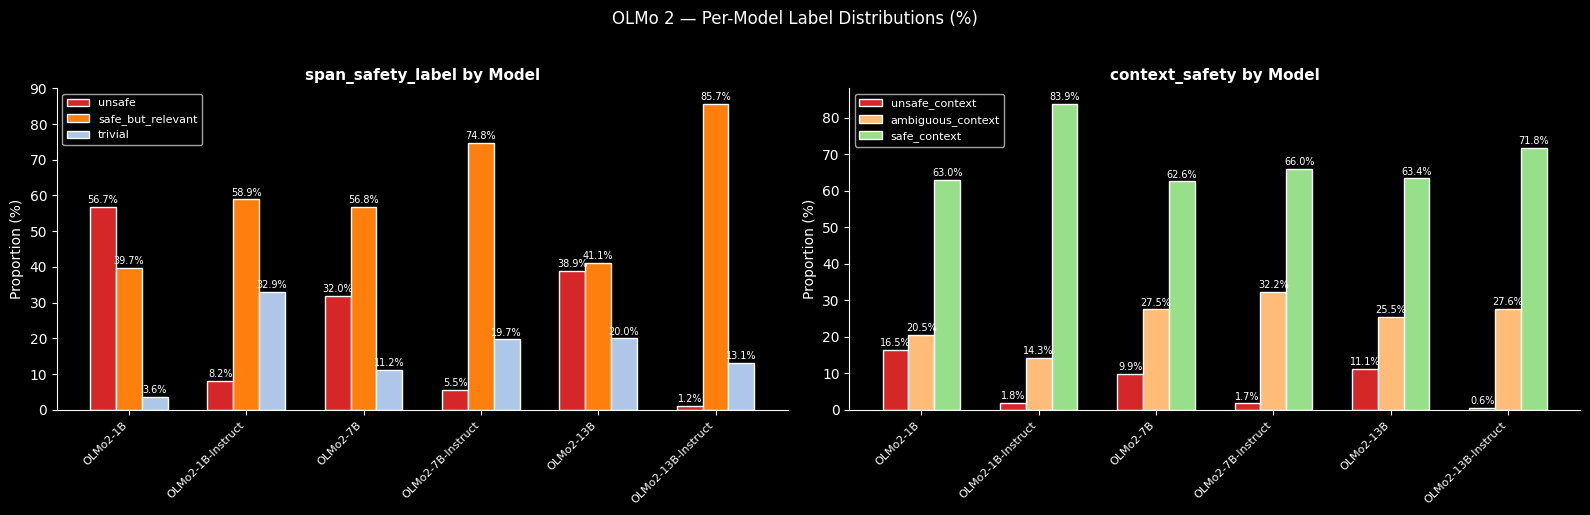

In [23]:
# ── 2.2: Per-model span_safety_label distribution (grouped bar chart) ──
model_labels = [cfg['label'] for cfg in MODEL_CONFIGS.values() if cfg['label'] in df_spans['model_label'].unique()]
span_order = ['unsafe', 'safe_but_relevant', 'trivial']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: span_safety_label proportions
ax = axes[0]
x = np.arange(len(model_labels))
width = 0.22
for i, cat in enumerate(span_order):
    vals = []
    for ml in model_labels:
        sub = df_spans[df_spans['model_label'] == ml]
        total = len(sub)
        count = (sub['span_safety_label'] == cat).sum()
        vals.append(count / total * 100 if total > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=cat, color=span_colors[cat], edgecolor='white')
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion (%)')
ax.set_title('span_safety_label by Model', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: context_safety proportions
ax = axes[1]
ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']
for i, cat in enumerate(ctx_order):
    vals = []
    for ml in model_labels:
        sub = df_all[df_all['model_label'] == ml]
        total = len(sub)
        count = (sub['context_safety'] == cat).sum()
        vals.append(count / total * 100 if total > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=cat, color=ctx_colors[cat], edgecolor='white')
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion (%)')
ax.set_title('context_safety by Model', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 — Per-Model Label Distributions (%)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_olmo2_per_model_labels.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Base vs. Instruct Comparison

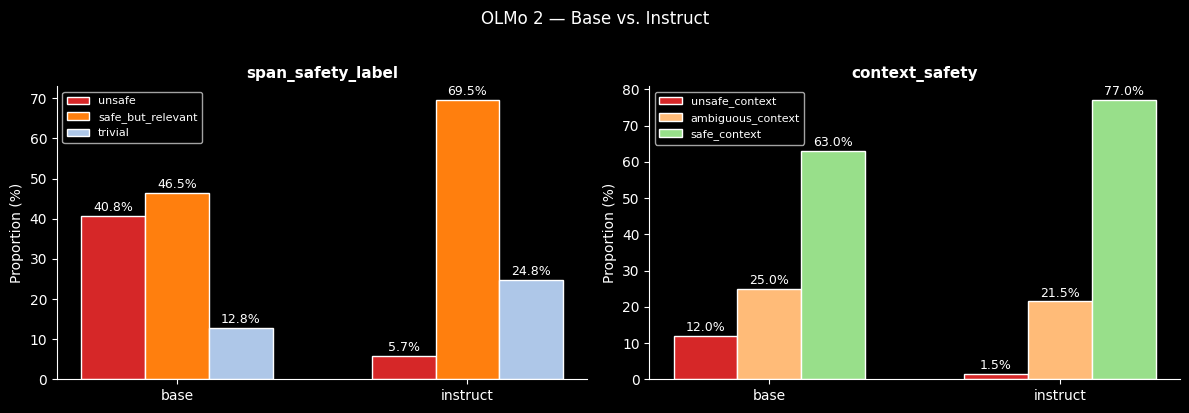

In [24]:
# ── 2.3: Base vs Instruct comparison ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, (label_col, label_order, colors, title, df_src) in enumerate([
    ('span_safety_label', ['unsafe', 'safe_but_relevant', 'trivial'], span_colors, 'span_safety_label', df_spans),
    ('context_safety', ['unsafe_context', 'ambiguous_context', 'safe_context'], ctx_colors, 'context_safety', df_all),
]):
    ax = axes[ax_idx]
    families = ['base', 'instruct']
    x = np.arange(len(families))
    width = 0.22
    
    for i, cat in enumerate(label_order):
        vals = []
        for fam in families:
            sub = df_src[df_src['family'] == fam]
            total = len(sub)
            count = (sub[label_col] == cat).sum()
            vals.append(count / total * 100 if total > 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=cat, color=colors[cat], edgecolor='white')
        for j, v in enumerate(vals):
            if v > 0:
                ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(families, fontsize=10)
    ax.set_ylabel('Proportion (%)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 — Base vs. Instruct', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_olmo2_base_vs_instruct.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Size Comparison (1B vs 7B vs 13B)

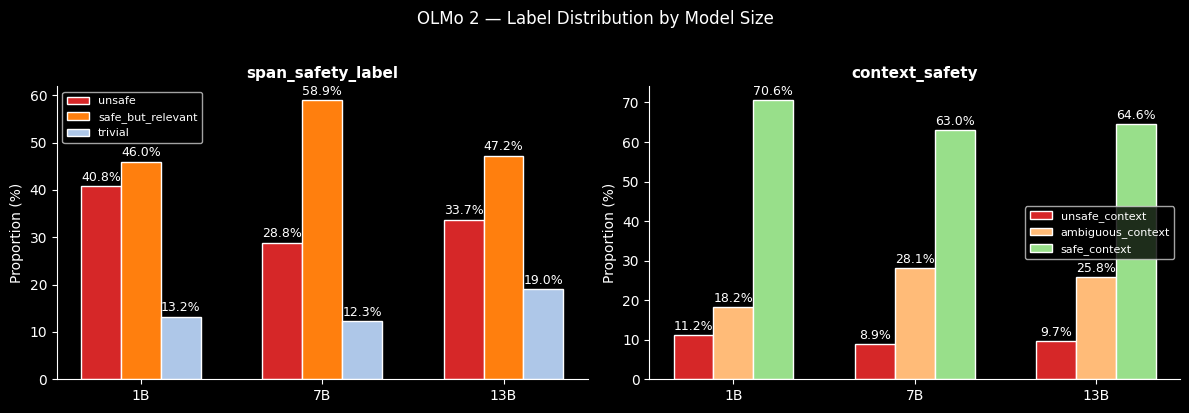

In [25]:
# ── 2.4: Size comparison ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sizes = ['1B', '7B', '13B']

for ax_idx, (label_col, label_order, colors, title, df_src) in enumerate([
    ('span_safety_label', ['unsafe', 'safe_but_relevant', 'trivial'], span_colors, 'span_safety_label', df_spans),
    ('context_safety', ['unsafe_context', 'ambiguous_context', 'safe_context'], ctx_colors, 'context_safety', df_all),
]):
    ax = axes[ax_idx]
    x = np.arange(len(sizes))
    width = 0.22
    
    for i, cat in enumerate(label_order):
        vals = []
        for sz in sizes:
            sub = df_src[df_src['size'] == sz]
            total = len(sub)
            count = (sub[label_col] == cat).sum()
            vals.append(count / total * 100 if total > 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=cat, color=colors[cat], edgecolor='white')
        for j, v in enumerate(vals):
            if v > 0:
                ax.text(x[j] + i * width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(sizes, fontsize=10)
    ax.set_ylabel('Proportion (%)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('OLMo 2 — Label Distribution by Model Size', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_olmo2_by_size.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** *(TODO: Compare how label distributions shift with model size and instruction tuning.)*

---
## Section 3: Per-Record Label Comparison

Stacked bar charts per model, mirroring GPT-J's Fig. 1. Each subplot shows one model's records.

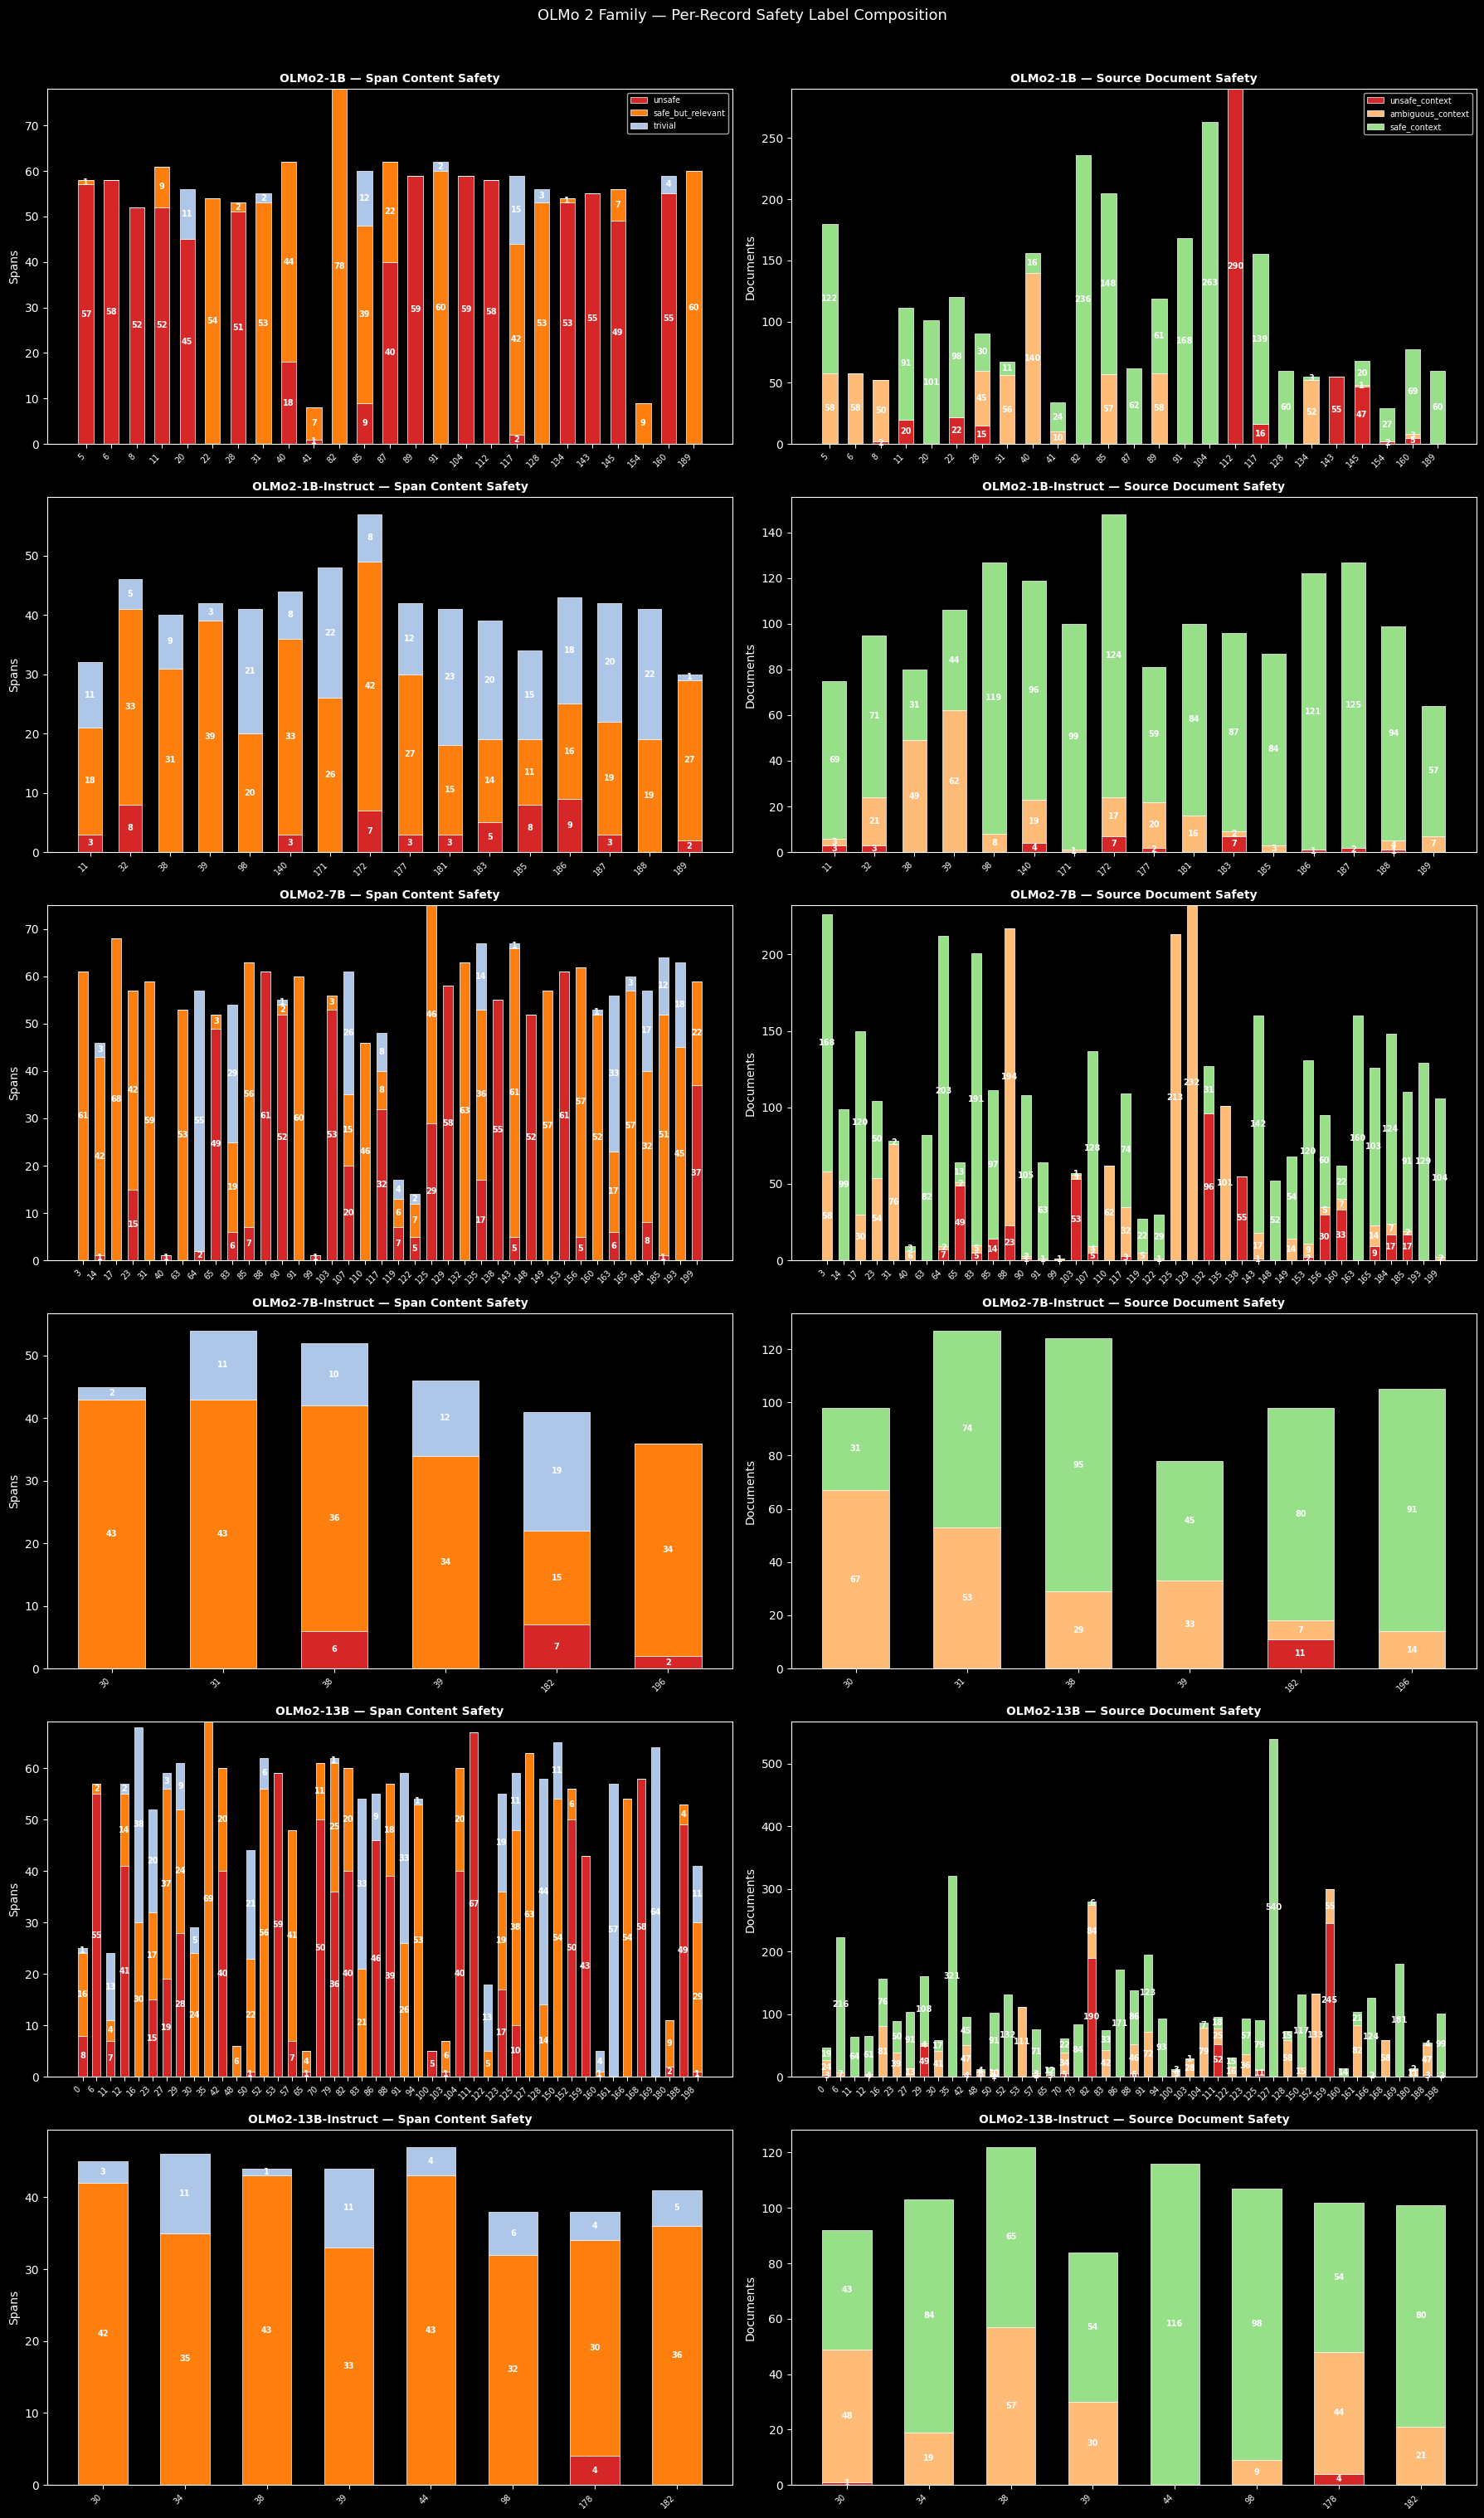

In [26]:
# ── Section 3: Per-record stacked bar charts — one subplot row per model ──

active_models = [md for md in MODEL_CONFIGS if md in df_spans['model_dir'].unique()]
n_models = len(active_models)

if n_models == 0:
    print("No model data available.")
else:
    fig, axes = plt.subplots(n_models, 2, figsize=(18, 5 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    span_cats = ['unsafe', 'safe_but_relevant', 'trivial']
    ctx_cats = ['unsafe_context', 'ambiguous_context', 'safe_context']
    
    for row_idx, model_dir in enumerate(active_models):
        cfg = MODEL_CONFIGS[model_dir]
        sub_spans = df_spans[df_spans['model_dir'] == model_dir]
        sub_all = df_all[df_all['model_dir'] == model_dir]
        record_ids = sorted(sub_spans['record_id'].unique())
        
        if len(record_ids) == 0:
            axes[row_idx, 0].text(0.5, 0.5, 'No records', ha='center', va='center', transform=axes[row_idx, 0].transAxes)
            axes[row_idx, 1].text(0.5, 0.5, 'No records', ha='center', va='center', transform=axes[row_idx, 1].transAxes)
            continue
        
        x = np.arange(len(record_ids))
        width = 0.6
        
        # Left: span_safety_label
        ax = axes[row_idx, 0]
        bottom = np.zeros(len(record_ids))
        for cat in span_cats:
            vals = np.array([(sub_spans[(sub_spans['record_id'] == rid) &
                                        (sub_spans['span_safety_label'] == cat)].shape[0])
                             for rid in record_ids])
            ax.bar(x, vals, width, bottom=bottom, label=cat,
                   color=span_colors[cat], edgecolor='white', linewidth=0.5)
            for j, v in enumerate(vals):
                if v > 0:
                    ax.text(x[j], bottom[j] + v / 2, str(v),
                            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
            bottom += vals
        
        ax.set_xticks(x)
        ax.set_xticklabels([f'{rid}' for rid in record_ids], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Spans')
        ax.set_title(f'{cfg["label"]} — Span Content Safety', fontsize=10, fontweight='bold')
        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=7)
        
        # Right: context_safety
        ax = axes[row_idx, 1]
        bottom = np.zeros(len(record_ids))
        for cat in ctx_cats:
            vals = np.array([(sub_all[(sub_all['record_id'] == rid) &
                                      (sub_all['context_safety'] == cat)].shape[0])
                             for rid in record_ids])
            ax.bar(x, vals, width, bottom=bottom, label=cat,
                   color=ctx_colors[cat], edgecolor='white', linewidth=0.5)
            for j, v in enumerate(vals):
                if v > 0:
                    ax.text(x[j], bottom[j] + v / 2, str(v),
                            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
            bottom += vals
        
        ax.set_xticks(x)
        ax.set_xticklabels([f'{rid}' for rid in record_ids], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Documents')
        ax.set_title(f'{cfg["label"]} — Source Document Safety', fontsize=10, fontweight='bold')
        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle('OLMo 2 Family — Per-Record Safety Label Composition', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_olmo2_per_record_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observation:** *(TODO: Compare per-record patterns across models. Do the same prompts produce similar label distributions across sizes?)*

---
## Section 4: Cross-Tabulation (Span Content × Source Document)

### 4.1 Overall Heatmap (All Models)

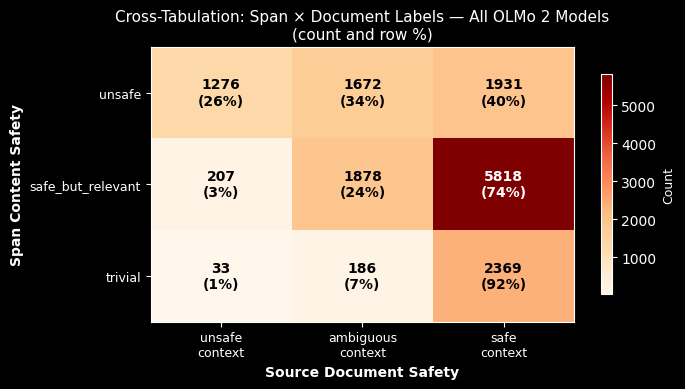

In [27]:
# ── 4.1: Overall cross-tabulation heatmap ──
span_order = ['unsafe', 'safe_but_relevant', 'trivial']
ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']

ct = pd.crosstab(df_all['span_safety_label'], df_all['context_safety'])
ct = ct.reindex(index=span_order, columns=ctx_order, fill_value=0)

# Annotate with count + row %
annot = ct.copy().astype(str)
row_pct = ct.div(ct.sum(axis=1), axis=0) * 100
for r in ct.index:
    for c in ct.columns:
        annot.loc[r, c] = f"{ct.loc[r, c]}\n({row_pct.loc[r, c]:.0f}%)"

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(ct.values, cmap='OrRd', aspect='auto')

for i in range(len(span_order)):
    for j in range(len(ctx_order)):
        val = ct.values[i, j]
        text_color = 'white' if val > ct.values.max() * 0.6 else 'black'
        ax.text(j, i, annot.values[i, j], ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_xticks(range(len(ctx_order)))
ax.set_xticklabels(['unsafe\ncontext', 'ambiguous\ncontext', 'safe\ncontext'], fontsize=9)
ax.set_yticks(range(len(span_order)))
ax.set_yticklabels(span_order, fontsize=9)
ax.set_xlabel('Source Document Safety', fontsize=10, fontweight='bold')
ax.set_ylabel('Span Content Safety', fontsize=10, fontweight='bold')
ax.set_title('Cross-Tabulation: Span × Document Labels — All OLMo 2 Models\n(count and row %)', fontsize=11)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Count', fontsize=9)

plt.tight_layout()
plt.savefig('fig_olmo2_cross_tab_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Per-Model Heatmap Comparison

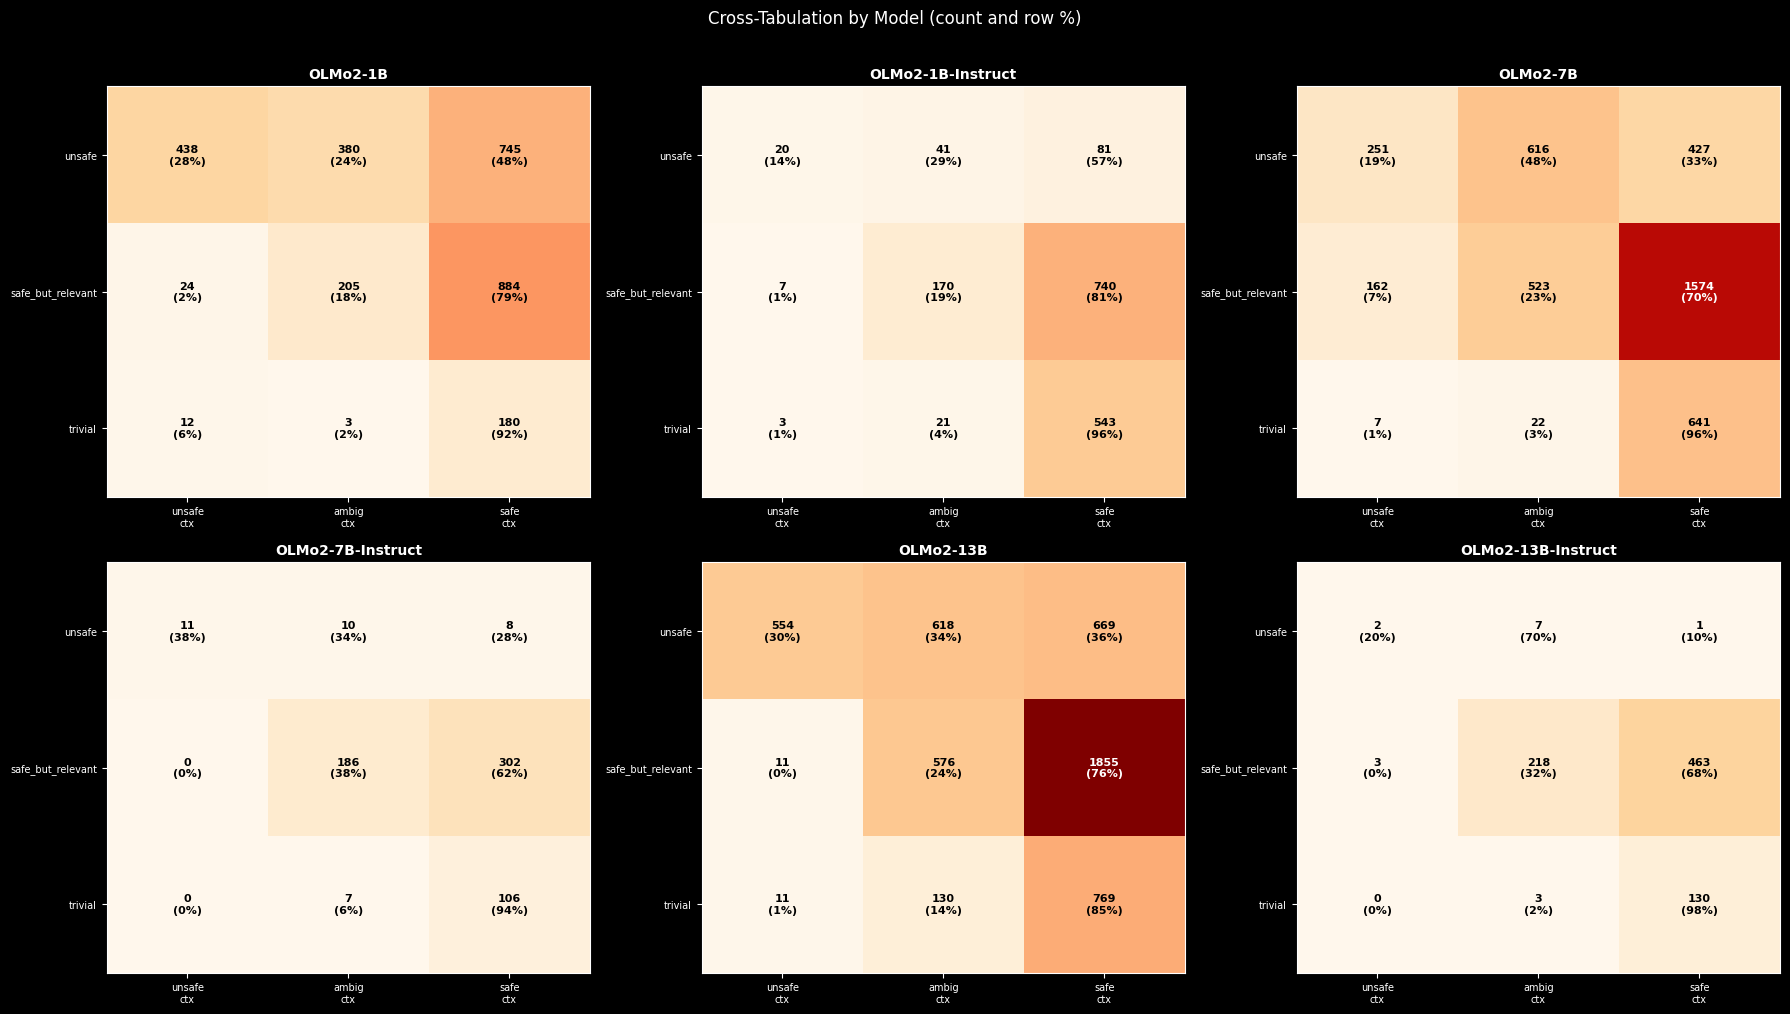

In [28]:
# ── 4.2: Per-model cross-tabulation heatmap subplots ──
active_models = [md for md in MODEL_CONFIGS if md in df_all['model_dir'].unique()]
n_models = len(active_models)

if n_models == 0:
    print("No model data available.")
else:
    n_cols = 3
    n_rows_grid = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(6 * n_cols, 5 * n_rows_grid))
    axes = np.atleast_2d(axes)
    
    span_order = ['unsafe', 'safe_but_relevant', 'trivial']
    ctx_order = ['unsafe_context', 'ambiguous_context', 'safe_context']
    
    # Find global max for consistent color scale
    global_max = 0
    for model_dir in active_models:
        sub = df_all[df_all['model_dir'] == model_dir]
        ct_tmp = pd.crosstab(sub['span_safety_label'], sub['context_safety'])
        ct_tmp = ct_tmp.reindex(index=span_order, columns=ctx_order, fill_value=0)
        global_max = max(global_max, ct_tmp.values.max())
    
    for idx, model_dir in enumerate(active_models):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        cfg = MODEL_CONFIGS[model_dir]
        
        sub = df_all[df_all['model_dir'] == model_dir]
        ct = pd.crosstab(sub['span_safety_label'], sub['context_safety'])
        ct = ct.reindex(index=span_order, columns=ctx_order, fill_value=0)
        
        row_pct = ct.div(ct.sum(axis=1).replace(0, 1), axis=0) * 100
        annot = ct.copy().astype(str)
        for ri in ct.index:
            for ci in ct.columns:
                annot.loc[ri, ci] = f"{ct.loc[ri, ci]}\n({row_pct.loc[ri, ci]:.0f}%)"
        
        im = ax.imshow(ct.values, cmap='OrRd', aspect='auto', vmin=0, vmax=global_max)
        
        for i in range(len(span_order)):
            for j in range(len(ctx_order)):
                val = ct.values[i, j]
                text_color = 'white' if val > global_max * 0.6 else 'black'
                ax.text(j, i, annot.values[i, j], ha='center', va='center',
                        fontsize=8, fontweight='bold', color=text_color)
        
        ax.set_xticks(range(len(ctx_order)))
        ax.set_xticklabels(['unsafe\nctx', 'ambig\nctx', 'safe\nctx'], fontsize=7)
        ax.set_yticks(range(len(span_order)))
        ax.set_yticklabels(span_order, fontsize=7)
        ax.set_title(cfg['label'], fontsize=10, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(n_models, n_rows_grid * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)
    
    plt.suptitle('Cross-Tabulation by Model (count and row %)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_olmo2_cross_tab_per_model.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observation:** *(TODO: Compare heatmap patterns across models. Does the dominant cell shift with size or instruction tuning?)*